 # Phase 4 - Modeling (price_log)



 We build and compare machine learning and deep learning models to **predict used car prices** using the prepared dataset from Phase 3.



 Because `price` is a continuous numeric target, we use a **regression** approach.



 In this notebook, we model **log-transformed price** (`price_log`) to handle the right-skewed distribution of used car prices.



 We:

 - Train the **selected best 5 models** and compare results.

 - Test a small set of hyperparameters and document improvements.

 - Evaluate with **R² on log scale**, and **MAE/RMSE reported in original price units** using back-transformed predictions with `exp()`.

 - Visualize predictions, residuals, and feature importance.



 80/20 train test split is used as our test design plan for consistent model comparison. The results of this modeling phase will be reviewed and finalized in the next phase.



 ## Load Dataset



 We load the prepared and encoded dataset from Phase 3 to begin price modeling.

 We verify the dataset shape and available features to confirm that the data is complete and ready for the train test split.



In [1]:
import pandas as pd

df = pd.read_csv("encoded_dataset.csv")

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.head()



Dataset shape: (2743730, 17)

Columns:
['price', 'year', 'combined_fuel_economy', 'mileage', 'fuel_type', 'transmission', 'body_type', 'engine_type', 'horsepower', 'torque', 'legroom', 'maximum_seating', 'size_of_vehicle', 'has_incidents', 'wheel_system', 'major_options_count', 'price_log']


,price,year,combined_fuel_economy,mileage,fuel_type,transmission,body_type,engine_type,horsepower,torque,legroom,maximum_seating,size_of_vehicle,has_incidents,wheel_system,major_options_count,price_log
0,83379.0,2019,73.5,323.000000,0,1,1,32,170.0,265.218839,80.166305,5,462.2,0,2,9.0,11.331152
1,24595.0,2021,52.0,1.000000,3,0,4,11,151.0,265.218839,79.700000,5,427.7,0,0,5.0,10.110298
2,21605.0,2020,34.0,6.000000,0,0,4,21,158.0,138.000000,79.700000,5,427.9,0,0,1.0,9.980680
3,28330.0,2020,28.0,31146.901467,0,1,1,21,187.0,186.000000,80.600000,5,449.6,0,0,4.0,10.251677
4,51975.0,2020,23.0,1.000000,0,1,4,1,300.0,295.000000,79.600000,5,450.8,0,2,8.0,10.858518


 ## Select Features and Train–Test Split



 We define `price_log` as the target and use the remaining columns as features for regression.

 To avoid duplicate targets, we drop `price` and keep the modeling target in log price units.



In [2]:
from sklearn.model_selection import train_test_split

df = df.drop(columns=["price"])

target = "price_log"
features = [c for c in df.columns if c != target]

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nFeatures used:", len(features))



Train shape: (2194984, 15)
Test shape: (548746, 15)

Features used: 15


 ## Scale Numerical Features



 To prepare the data for modeling, the numerical features are standardized using `StandardScaler`.

 This ensures that models sensitive to feature magnitude (such as MLP) train effectively.



In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled[:2]



array([[-0.43347217, -0.93892414,  1.02930395, -0.26652733,  0.2832443 ,
         1.82775335,  0.70060434,  1.22586719,  1.09071371, -0.11152251,
         0.49181392,  1.68496903, -0.25580504, -0.02487053, -0.39117271],
       [-0.43347217, -0.87339255,  0.24943588,  1.01774768,  0.2832443 ,
         1.82775335,  0.20595679,  0.67478897,  1.34011344, -1.3764663 ,
         0.49181392,  1.66862196, -0.25580504, -0.02487053, -0.68123684]])

 ## Random Forest Regressor (Untuned)



 A Random Forest model is trained to capture non-linear relationships in the data.

 This model typically performs well on large and complex datasets.



In [4]:
# train

from sklearn.ensemble import RandomForestRegressor
import time

rf = RandomForestRegressor(
    n_estimators=50,
    max_depth=None,
    n_jobs=-1,
    random_state=42
)

_start = time.perf_counter()
rf.fit(X_train, y_train)
rf_time = time.perf_counter() - _start



In [5]:
# predict

rf_preds = rf.predict(X_test)
rf_preds[:5]



array([10.87100228,  9.74493393, 10.62454436,  9.97701031, 10.05466885])

In [6]:
# metrics

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

y_test_raw = np.exp(y_test)
rf_preds_raw = np.exp(rf_preds)

rf_r2 = r2_score(y_test, rf_preds)
rf_mae = mean_absolute_error(y_test_raw, rf_preds_raw)
rf_rmse = np.sqrt(mean_squared_error(y_test_raw, rf_preds_raw))

print("Random Forest Metrics (Log Target)")
print("R² (log):", rf_r2)
print("MAE (raw):", rf_mae)
print("RMSE (raw):", rf_rmse)



Random Forest Metrics (Log Target)
R² (log): 0.9438221992055956
MAE (raw): 2444.8831935305093
RMSE (raw): 5807.27205455761


Random Forest is very strong in log space (R² = 0.944) and keeps raw-price errors low (MAE ≈ $2.4k, RMSE ≈ $5.8k).
The log target likely helps it handle high-priced outliers while still learning the non-linear interactions of year, mileage, horsepower, torque, and size.


 #### Random Forest Feature Importance and Visualizations



 To understand how the model prioritizes different attributes, feature importances are extracted from the Random Forest.

 Visualizations are also generated to compare actual vs predicted values and to examine residual patterns (in original price units).



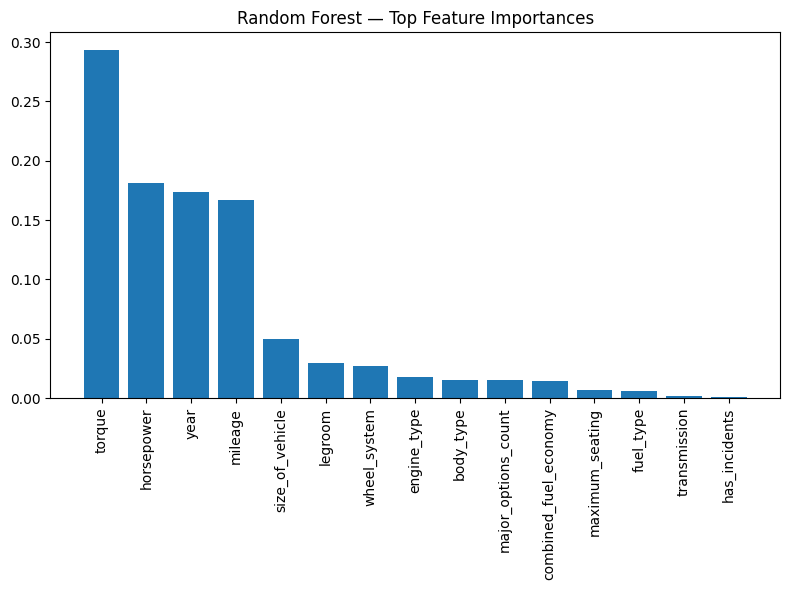

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
top_n = 15

plt.figure(figsize=(8, 6))
plt.bar(range(top_n), importances[indices][:top_n])
plt.xticks(range(top_n), [features[i] for i in indices][:top_n], rotation=90)
plt.title("Random Forest — Top Feature Importances")
plt.tight_layout()
plt.show()



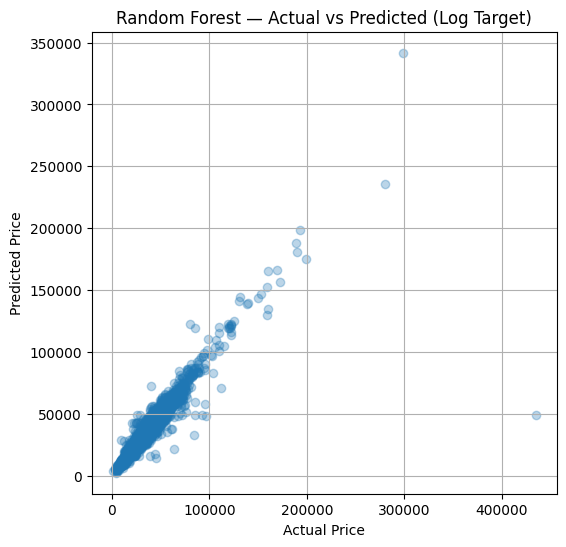

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test_raw[:5000], rf_preds_raw[:5000], alpha=0.3)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Random Forest — Actual vs Predicted (Log Target)")
plt.grid(True)
plt.show()



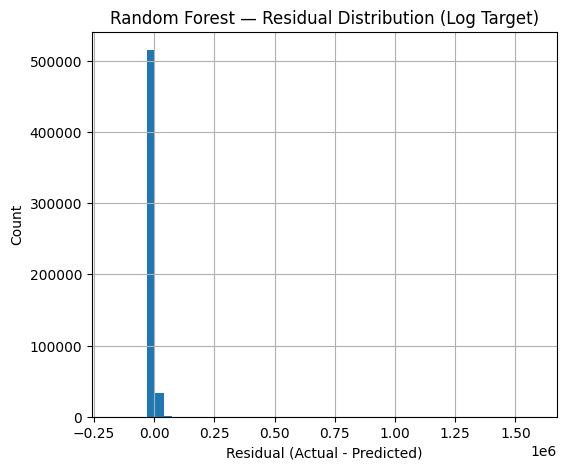

In [ ]:
rf_residuals = y_test_raw - rf_preds_raw

plt.figure(figsize=(6, 5))
plt.hist(rf_residuals, bins=50)
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Count")
plt.title("Random Forest — Residual Distribution (Log Target)")
plt.grid(True)
plt.show()



Torque/horsepower, year, and mileage dominate, meaning performance + age + usage are still the main drivers of price even after smoothing skew with the log target.

 ## XGBoost Regressor (Untuned)



 An XGBoost model is trained to evaluate performance using gradient-boosted decision trees.

 XGBoost often provides strong predictive accuracy on structured tabular data.



In [10]:
# train

from xgboost import XGBRegressor
import time

xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    random_state=42
)

_start = time.perf_counter()
xgb.fit(X_train, y_train)
xgb_time = time.perf_counter() - _start



In [11]:
# predict

xgb_preds = xgb.predict(X_test)
xgb_preds[:5]



array([10.8828945,  9.72804  , 10.692528 , 10.070204 , 10.157758 ],
      dtype=float32)

In [12]:
# metrics

xgb_preds_raw = np.exp(xgb_preds)

xgb_r2 = r2_score(y_test, xgb_preds)
xgb_mae = mean_absolute_error(y_test_raw, xgb_preds_raw)
xgb_rmse = np.sqrt(mean_squared_error(y_test_raw, xgb_preds_raw))

print("XGBoost Metrics (Log Target)")
print("R² (log):", xgb_r2)
print("MAE (raw):", xgb_mae)
print("RMSE (raw):", xgb_rmse)



XGBoost Metrics (Log Target)
R² (log): 0.931294625821421
MAE (raw): 2968.264889875711
RMSE (raw): 6725.434892247301


XGBoost with log target is performing strongly, explaining most of the variation in log(price), but its raw-price errors are a bit higher than the log-based Random Forest.
This likely means it captures the overall pricing pattern well but is slightly less stable on extreme/high-price cases.

 #### XGBoost Feature Importance and Visualizations



 Feature importances and evaluation plots are generated for the XGBoost model.

 These help interpret how each variable contributes to price prediction.



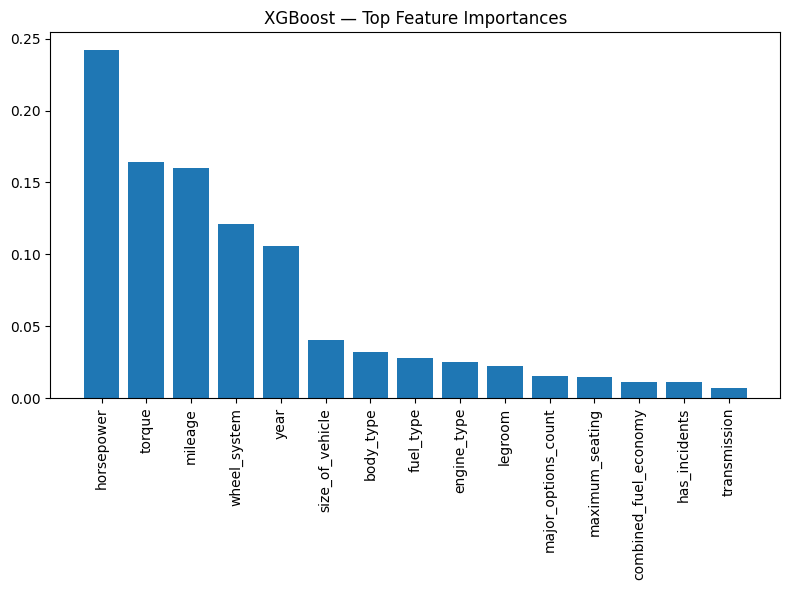

In [ ]:
xgb_importances = xgb.feature_importances_
indices_xgb = np.argsort(xgb_importances)[::-1]
top_n = 15

plt.figure(figsize=(8, 6))
plt.bar(range(top_n), xgb_importances[indices_xgb][:top_n])
plt.xticks(range(top_n), [features[i] for i in indices_xgb][:top_n], rotation=90)
plt.title("XGBoost — Top Feature Importances")
plt.tight_layout()
plt.show()



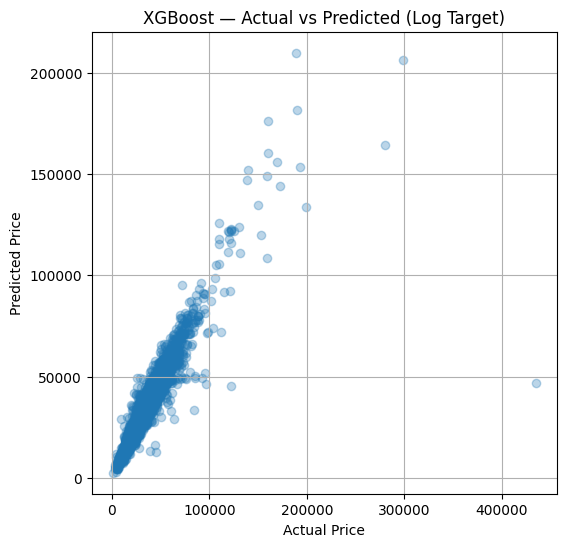

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test_raw[:5000], xgb_preds_raw[:5000], alpha=0.3)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("XGBoost — Actual vs Predicted (Log Target)")
plt.grid(True)
plt.show()



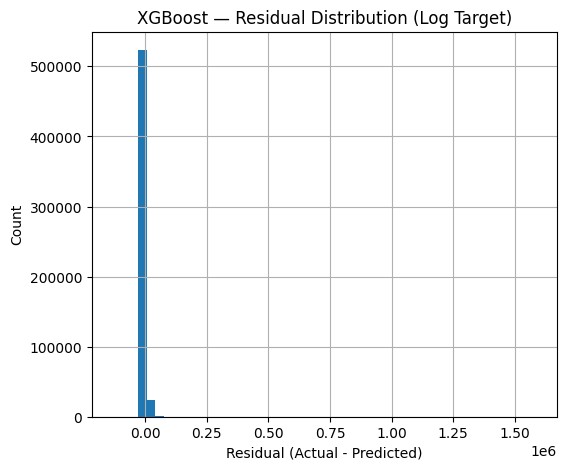

In [ ]:
xgb_residuals = y_test_raw - xgb_preds_raw

plt.figure(figsize=(6, 5))
plt.hist(xgb_residuals, bins=50)
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Count")
plt.title("XGBoost — Residual Distribution (Log Target)")
plt.grid(True)
plt.show()



XGBoost with log target shows a tight actual vs predicted pattern for most cars, so the model is handling the wide price range better than with raw price.
Residuals are more centered with fewer extreme errors, and the importance plot suggests price is still mainly driven by horsepower, torque, mileage, wheel system, and yea

 ## CatBoost Regressor (Untuned)



 A CatBoost model is trained to evaluate another powerful gradient boosting method.

 It can perform strongly on structured tabular data.



In [16]:
from catboost import CatBoostRegressor

# train
cb = CatBoostRegressor(
    iterations=300,
    learning_rate=0.1,
    depth=6,
    random_state=42,
    verbose=0
)

_start = time.perf_counter()
cb.fit(X_train, y_train)
cb_time = time.perf_counter() - _start



In [17]:
# predict
cb_preds = cb.predict(X_test)
cb_preds[:5]



array([10.85609387,  9.74425777, 10.65498858, 10.06714325, 10.24883758])

In [18]:
# metrics

cb_preds_raw = np.exp(cb_preds)

cb_r2 = r2_score(y_test, cb_preds)
cb_mae = mean_absolute_error(y_test_raw, cb_preds_raw)
cb_rmse = np.sqrt(mean_squared_error(y_test_raw, cb_preds_raw))

print("CatBoost Metrics (Log Target)")
print("R² (log):", cb_r2)
print("MAE (raw):", cb_mae)
print("RMSE (raw):", cb_rmse)



CatBoost Metrics (Log Target)
R² (log): 0.9140331876984417
MAE (raw): 3411.6663394951092
RMSE (raw): 7547.142639328211


CatBoost with log target still captures the main price patterns well, but its error is higher than RF/XGB in this setup, so it looks slightly less stable on this dataset.
This may be because the relationships here are better matched by the other boosted/tree configurations, especially when handling very high-priced outliers.


 #### CatBoost Visualizations

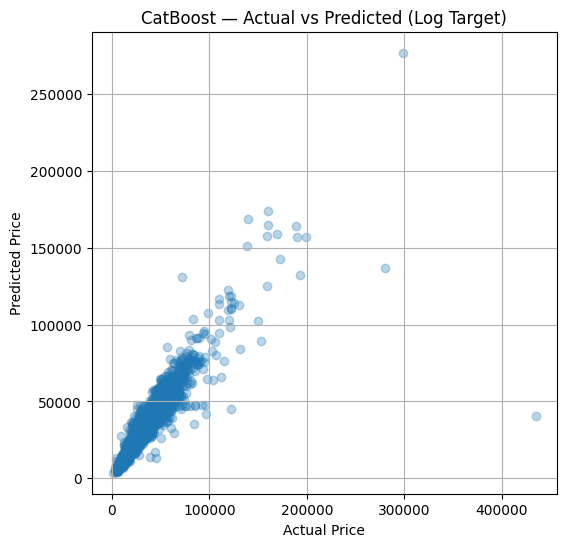

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test_raw[:5000], cb_preds_raw[:5000], alpha=0.3)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("CatBoost — Actual vs Predicted (Log Target)")
plt.grid(True)
plt.show()


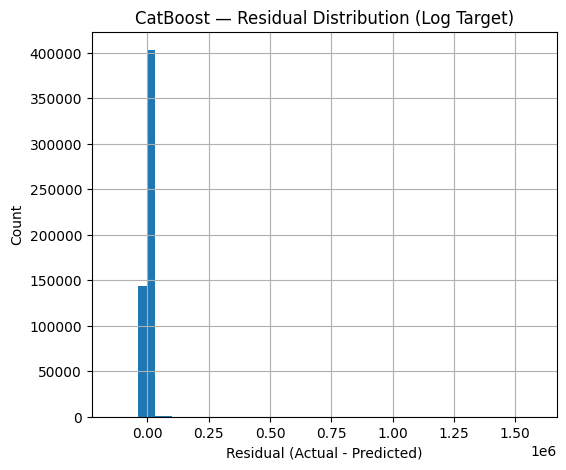

In [ ]:
cb_residuals = y_test_raw - cb_preds_raw

plt.figure(figsize=(6, 5))
plt.hist(cb_residuals, bins=50)
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Count")
plt.title("CatBoost — Residual Distribution (Log Target)")
plt.grid(True)
plt.show()



CatBoost with log target looks solid overall: the actual vs predicted points mostly follow the diagonal, so it’s capturing the main price patterns well, especially in the common price range.

The residuals are tightly centered around zero, which suggests stable predictions for most cars, but the long tail hints that very expensive or unusual listings still create bigger errors.


 ## LightGBM Regressor (Untuned)



 A LightGBM model is trained to compare another gradient boosting framework

 known for speed and strong performance.



In [21]:
from lightgbm import LGBMRegressor

# train
lgbm = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=-1
)

_start = time.perf_counter()
lgbm.fit(X_train, y_train)
lgbm_time = time.perf_counter() - _start



[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.316041 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1456
[LightGBM] [Info] Number of data points in the train set: 2194984, number of used features: 15
[LightGBM] [Info] Start training from score 10.237952


In [22]:
# predict
lgbm_preds = lgbm.predict(X_test)
lgbm_preds[:5]



array([10.86060384,  9.71078093, 10.6390431 , 10.05745515, 10.1966778 ])

In [23]:
# metrics

lgbm_preds_raw = np.exp(lgbm_preds)

lgbm_r2 = r2_score(y_test, lgbm_preds)
lgbm_mae = mean_absolute_error(y_test_raw, lgbm_preds_raw)
lgbm_rmse = np.sqrt(mean_squared_error(y_test_raw, lgbm_preds_raw))

print("LightGBM Metrics (Log Target)")
print("R² (log):", lgbm_r2)
print("MAE (raw):", lgbm_mae)
print("RMSE (raw):", lgbm_rmse)



LightGBM Metrics (Log Target)
R² (log): 0.9203983342606087
MAE (raw): 3251.3905548991934
RMSE (raw): 7215.271533267887


LightGBM with log target performs strongly, with high R² and lower errors than CatBoost here, suggesting it generalizes well across the typical market price range.

The log transformation likely helped it handle the wide price spread, reducing the impact of extreme high-price cars and giving more stable MAE/RMSE in raw dollars.


 #### LightGBM Visualizations

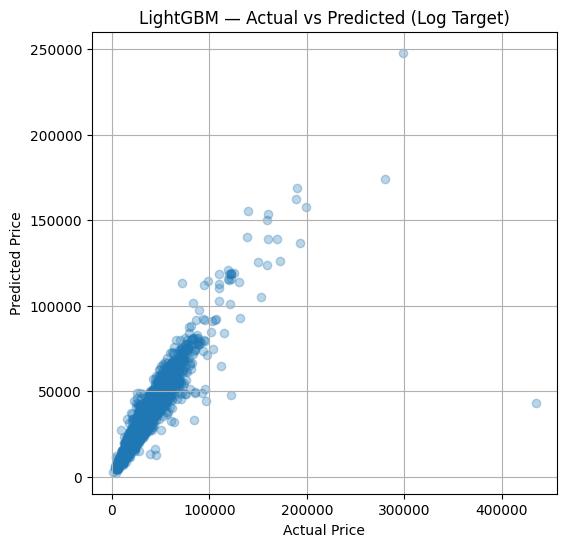

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test_raw[:5000], lgbm_preds_raw[:5000], alpha=0.3)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("LightGBM — Actual vs Predicted (Log Target)")
plt.grid(True)
plt.show()


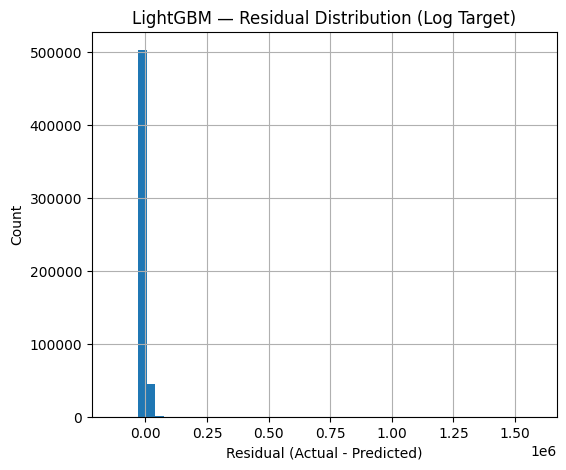

In [ ]:
lgbm_residuals = y_test_raw - lgbm_preds_raw

plt.figure(figsize=(6, 5))
plt.hist(lgbm_residuals, bins=50)
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Count")
plt.title("LightGBM — Residual Distribution (Log Target)")
plt.grid(True)
plt.show()



The scatter suggests good alignment with actual prices across the bulk of the dataset, indicating the log target helped LightGBM generalize well beyond simple linear patterns. The residuals are narrow and centered, so most errors are modest in raw dollars, with remaining larger misses likely coming from rare high-end listings.

 ## MLP Regressor (Deep Learning, Untuned)



 A Multi-Layer Perceptron neural network is trained as the deep learning model for price prediction.

 Neural networks can capture complex non-linear relationships when trained on standardized numerical features.



In [ ]:
# train

from sklearn.neural_network import MLPRegressor

mlp = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    max_iter=5,
    random_state=42
)

_start = time.perf_counter()
mlp.fit(X_train_scaled, y_train)
mlp_time = time.perf_counter() - _start



In [27]:
# predict

mlp_preds = mlp.predict(X_test_scaled)
mlp_preds[:5]



array([10.80504922,  9.60233845, 10.58926979, 10.01866281, 10.11596743])

In [28]:
# metrics

mlp_preds_raw = np.exp(mlp_preds)

mlp_r2 = r2_score(y_test, mlp_preds)
mlp_mae = mean_absolute_error(y_test_raw, mlp_preds_raw)
mlp_rmse = np.sqrt(mean_squared_error(y_test_raw, mlp_preds_raw))

print("MLP Regressor Metrics (Log Target)")
print("R² (log):", mlp_r2)
print("MAE (raw):", mlp_mae)
print("RMSE (raw):", mlp_rmse)



MLP Regressor Metrics (Log Target)
R² (log): 0.8870421393342978
MAE (raw): 3774.7812486211615
RMSE (raw): 8664.564472634931


MLP improves with log(price), but its raw MAE/RMSE are still higher, meaning it struggles more with extreme prices than the tree models.

 #### MLP Regressor Visualizations



 The prediction results from the neural network model are visualized through:

 - Actual vs Predicted scatter plot

 - Residual distribution plot



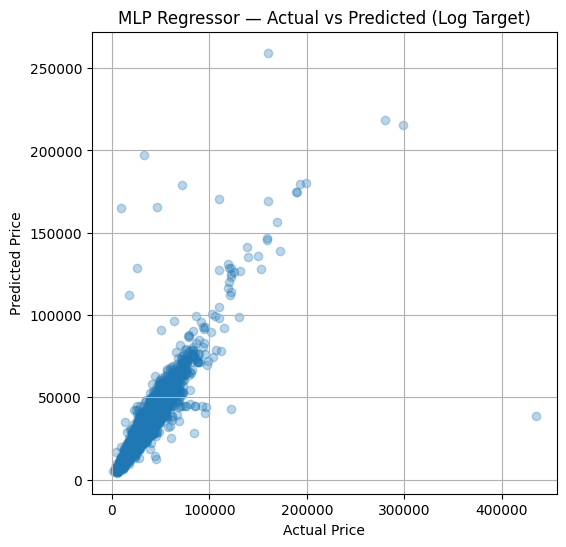

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test_raw[:5000], mlp_preds_raw[:5000], alpha=0.3)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("MLP Regressor — Actual vs Predicted (Log Target)")
plt.grid(True)
plt.show()



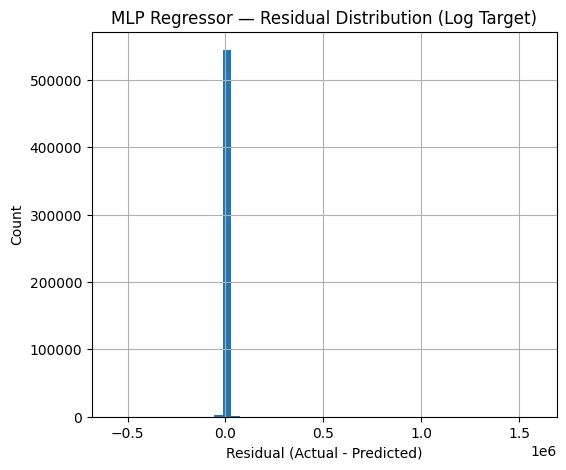

In [ ]:
mlp_residuals = y_test_raw - mlp_preds_raw

plt.figure(figsize=(6, 5))
plt.hist(mlp_residuals, bins=50)
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Count")
plt.title("MLP Regressor — Residual Distribution (Log Target)")
plt.grid(True)
plt.show()



The MLP improves with the log target but still shows wider spread for higher-priced cars, so it struggles more than tree models with rare extreme cases.

 ## Hyperparameter Tuning (400,000-row Sample)



 We tune models on a 400,000-row sample from the training set to keep computation practical.

 This lets us check whether small hyperparameter changes improve performance before retraining on the full training data.



 We use small grids for the selected top 5 models:

 - Random Forest

 - XGBoost

 - CatBoost

 - LightGBM

 - MLP



In [31]:
import pandas as pd

train_df = df.loc[X_train.index].copy()

df_sample = train_df.sample(400000, random_state=42)

X_sample = df_sample[features]
y_sample = df_sample[target]



In [32]:
scaler_sample = StandardScaler()
X_sample_scaled = scaler_sample.fit_transform(X_sample)



 ### Random Forest Tuning

 A small grid was used to evaluate tree depth and number of estimators.

 This typically improves performance while keeping the model efficient.



In [33]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

rf_grid = {
    "n_estimators": [50, 100],
    "max_depth": [10, 20, None]
}

rf_base = RandomForestRegressor(n_jobs=-1, random_state=42)

rf_search = GridSearchCV(
    rf_base,
    rf_grid,
    cv=3,
    scoring="r2",
    verbose=1
)

rf_search.fit(X_sample, y_sample)

print("RF Best Params:", rf_search.best_params_)
print("RF Best R2:", rf_search.best_score_)



Fitting 3 folds for each of 6 candidates, totalling 18 fits
RF Best Params: {'max_depth': 20, 'n_estimators': 100}
RF Best R2: 0.9357896777931768


 ### XGBoost Tuning

 A lightweight parameter grid was used to keep training efficient.

 XGBoost is computationally heavier, so cv=2 was used.



In [34]:
from xgboost import XGBRegressor

xgb_grid = {
    "n_estimators": [100, 200],
    "max_depth": [6, 8],
    "learning_rate": [0.05, 0.1]
}

xgb_base = XGBRegressor(
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    random_state=42
)

xgb_search = GridSearchCV(
    xgb_base,
    xgb_grid,
    cv=2,
    scoring="r2",
    verbose=1
)

xgb_search.fit(X_sample, y_sample)

print("XGB Best Params:", xgb_search.best_params_)
print("XGB Best R2:", xgb_search.best_score_)



Fitting 2 folds for each of 8 candidates, totalling 16 fits
XGB Best Params: {'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 200}
XGB Best R2: 0.9329064899154487


 ### CatBoost Tuning

 A small grid is used to test key CatBoost parameters efficiently.

In [35]:
from catboost import CatBoostRegressor

cb_grid = {
    "iterations": [300, 600],
    "learning_rate": [0.05, 0.1],
    "depth": [6, 8]
}

cb_base = CatBoostRegressor(
    random_state=42,
    verbose=0
)

cb_search = GridSearchCV(
    cb_base,
    cb_grid,
    cv=2,
    scoring="r2",
    verbose=1
)

cb_search.fit(X_sample, y_sample)

print("CatBoost Best Params:", cb_search.best_params_)
print("CatBoost Best R2:", cb_search.best_score_)



Fitting 2 folds for each of 8 candidates, totalling 16 fits
CatBoost Best Params: {'depth': 8, 'iterations': 600, 'learning_rate': 0.1}
CatBoost Best R2: 0.930977192877993


 ### LightGBM Tuning



 A small grid is used to tune estimators, learning rate, and leaf complexity.

In [36]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import GridSearchCV

lgbm_grid = {
    "n_estimators": [200, 500],
    "learning_rate": [0.05, 0.1],
    "num_leaves": [31, 50, 70]
}

lgbm_base = LGBMRegressor(
    random_state=42,
    n_jobs=-1,
    verbose=-1,
    force_row_wise=True
)

lgbm_search = GridSearchCV(
    lgbm_base,
    lgbm_grid,
    cv=3,
    scoring="r2",
    verbose=1
)

lgbm_search.fit(X_sample, y_sample)

print("LightGBM Best Params:", lgbm_search.best_params_)
print("LightGBM Best R2:", lgbm_search.best_score_)



Fitting 3 folds for each of 12 candidates, totalling 36 fits
LightGBM Best Params: {'learning_rate': 0.1, 'n_estimators': 500, 'num_leaves': 70}
LightGBM Best R2: 0.9376947143512644


 ### MLP Regressor Tuning

 Neural networks are computationally expensive, so a very small grid was used.

 The goal is to show improvement, not full deep-learning optimization.

We used a small grid on a scaled training sample with cv=2 and max_iter=5 as a quick, CPU-feasible parameter screening step for the 2.7M-row dataset.

In [ ]:
from sklearn.neural_network import MLPRegressor

mlp_grid = {
    "hidden_layer_sizes": [(64,32), (128,64,32)],
    "learning_rate_init": [0.001, 0.0005]
}

mlp_base = MLPRegressor(
    max_iter=5,
    random_state=42
)

mlp_search = GridSearchCV(
    mlp_base,
    mlp_grid,
    cv=2,
    scoring="r2",
    verbose=1
)

mlp_search.fit(X_sample_scaled, y_sample)

print("MLP Best Params:", mlp_search.best_params_)
print("MLP Best R2:", mlp_search.best_score_)



Fitting 2 folds for each of 4 candidates, totalling 8 fits
MLP Best Params: {'hidden_layer_sizes': (128, 64, 32), 'learning_rate_init': 0.001}
MLP Best R2: 0.8513160978440278


 What we see:



 On the tuning sample, the selected tree-based models lead strongly on the log target, while MLP remains behind.

 This supports our earlier conclusion that non-linear tree ensembles are the best fit for used car price prediction.



 ## Retrain Tuned Models on Full Dataset



 We now retrain the tuned versions of our selected five models using the full training set.

 Final evaluation is performed on the unchanged test set.



 ### Retrain Tuned Random Forest on Full Dataset



 We retrain Random Forest on the full training set using the best tuning results

 (`n_estimators=100`, `max_depth=20`).

 We then evaluate on the unchanged test set to confirm whether tuning improves the untuned baseline.



In [ ]:
rf_tuned = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    n_jobs=-1,
    random_state=42
)

_start = time.perf_counter()
rf_tuned.fit(X_train, y_train)
rf_tuned_time = time.perf_counter() - _start



In [39]:
# Predict + Metrics

rf_tuned_preds = rf_tuned.predict(X_test)
rf_tuned_preds_raw = np.exp(rf_tuned_preds)

rf_tuned_r2 = r2_score(y_test, rf_tuned_preds)
rf_tuned_mae = mean_absolute_error(y_test_raw, rf_tuned_preds_raw)
rf_tuned_rmse = np.sqrt(mean_squared_error(y_test_raw, rf_tuned_preds_raw))

print("Tuned Random Forest Metrics (Log Target)")
print("R² (log):", rf_tuned_r2)
print("MAE (raw):", rf_tuned_mae)
print("RMSE (raw):", rf_tuned_rmse)



Tuned Random Forest Metrics (Log Target)
R² (log): 0.9456355441338415
MAE (raw): 2441.823387992053
RMSE (raw): 5823.260650335786


Tiny change only; R² and MAE improve slightly, while RMSE is almost the same, so the default RF was already near-optimal for this data.

 ### Retrain Tuned XGBoost on Full Dataset



 The XGBoost model is retrained on the full training set using the best hyperparameters found during tuning

 (`learning_rate=0.05`, `max_depth=8`, `n_estimators=100`).

 The tuned model is then evaluated on the full test set.



In [ ]:
xgb_tuned = XGBRegressor(
    learning_rate=0.05,
    max_depth=8,
    n_estimators=100,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    random_state=42
)

_start = time.perf_counter()
xgb_tuned.fit(X_train, y_train)
xgb_tuned_time = time.perf_counter() - _start



In [41]:
# Predict + Metrics

xgb_tuned_preds = xgb_tuned.predict(X_test)
xgb_tuned_preds_raw = np.exp(xgb_tuned_preds)

xgb_tuned_r2 = r2_score(y_test, xgb_tuned_preds)
xgb_tuned_mae = mean_absolute_error(y_test_raw, xgb_tuned_preds_raw)
xgb_tuned_rmse = np.sqrt(mean_squared_error(y_test_raw, xgb_tuned_preds_raw))

print("Tuned XGBoost Metrics (Log Target)")
print("R² (log):", xgb_tuned_r2)
print("MAE (raw):", xgb_tuned_mae)
print("RMSE (raw):", xgb_tuned_rmse)



Tuned XGBoost Metrics (Log Target)
R² (log): 0.9213110617262648
MAE (raw): 3223.93372431868
RMSE (raw): 7180.591564405874


Tuning made it worse on the test set, likely because the small tuning sample/grid didn’t match the full data patterns and the default settings were already a strong fit.

 ### Retrain Tuned CatBoost on Full Dataset

In [ ]:
cb_tuned = CatBoostRegressor(
    **cb_search.best_params_,
    random_state=42,
    verbose=0
)

_start = time.perf_counter()
cb_tuned.fit(X_train, y_train)
cb_tuned_time = time.perf_counter() - _start



In [43]:
# Predict + Metrics

cb_tuned_preds = cb_tuned.predict(X_test)
cb_tuned_preds_raw = np.exp(cb_tuned_preds)

cb_tuned_r2 = r2_score(y_test, cb_tuned_preds)
cb_tuned_mae = mean_absolute_error(y_test_raw, cb_tuned_preds_raw)
cb_tuned_rmse = np.sqrt(mean_squared_error(y_test_raw, cb_tuned_preds_raw))

print("Tuned CatBoost Metrics (Log Target)")
print("R² (log):", cb_tuned_r2)
print("MAE (raw):", cb_tuned_mae)
print("RMSE (raw):", cb_tuned_rmse)



Tuned CatBoost Metrics (Log Target)
R² (log): 0.9350471978024991
MAE (raw): 2850.096450252377
RMSE (raw): 6492.389699510804


Clear improvement in both R² and raw errors, so CatBoost benefits a lot from better depth/iterations to capture the dataset’s non-linear price structure.

 ### Retrain Tuned LightGBM on Full Dataset

In [ ]:
lgbm_tuned = LGBMRegressor(
    **lgbm_search.best_params_,
    random_state=42,
    n_jobs=-1
)

_start = time.perf_counter()
lgbm_tuned.fit(X_train, y_train)
lgbm_tuned_time = time.perf_counter() - _start



In [45]:
# Predict + Metrics

lgbm_tuned_preds = lgbm_tuned.predict(X_test)
lgbm_tuned_preds_raw = np.exp(lgbm_tuned_preds)

lgbm_tuned_r2 = r2_score(y_test, lgbm_tuned_preds)
lgbm_tuned_mae = mean_absolute_error(y_test_raw, lgbm_tuned_preds_raw)
lgbm_tuned_rmse = np.sqrt(mean_squared_error(y_test_raw, lgbm_tuned_preds_raw))

print("Tuned LightGBM Metrics (Log Target)")
print("R² (log):", lgbm_tuned_r2)
print("MAE (raw):", lgbm_tuned_mae)
print("RMSE (raw):", lgbm_tuned_rmse)



Tuned LightGBM Metrics (Log Target)
R² (log): 0.9420508858554878
MAE (raw): 2655.4766255980367
RMSE (raw): 6095.335237130591


Big jump from the untuned version, suggesting the chosen leaves/learning rate/estimators helped it learn price patterns more cleanly without overfitting.

 ### Retrain Tuned MLP Regressor on Full Dataset



 The tuned MLP Regressor (`hidden_layer_sizes=(128,64,32)`, `learning_rate_init=0.001`)

 is retrained on the full standardized training set. The final performance is evaluated using R² (log), MAE (raw), and RMSE (raw).

 We used a small max_iter for quick comparison; performance may improve with longer training



In [ ]:
mlp_tuned = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    learning_rate_init=0.001,
    max_iter=5,
    random_state=42
)

_start = time.perf_counter()
mlp_tuned.fit(X_train_scaled, y_train)
mlp_tuned_time = time.perf_counter() - _start


In [47]:
# Predict + Metrics

mlp_tuned_preds = mlp_tuned.predict(X_test_scaled)
mlp_tuned_preds_raw = np.exp(mlp_tuned_preds)

mlp_tuned_r2 = r2_score(y_test, mlp_tuned_preds)
mlp_tuned_mae = mean_absolute_error(y_test_raw, mlp_tuned_preds_raw)
mlp_tuned_rmse = np.sqrt(mean_squared_error(y_test_raw, mlp_tuned_preds_raw))

print("Tuned MLP Metrics (Log Target)")
print("R² (log):", mlp_tuned_r2)
print("MAE (raw):", mlp_tuned_mae)
print("RMSE (raw):", mlp_tuned_rmse)



Tuned MLP Metrics (Log Target)
R² (log): 0.8870421393342978
MAE (raw): 3774.7812486211615
RMSE (raw): 8664.564472634931


No real change, meaning the “tuned” setup is effectively the same performance as baseline, and trees still handle this structured dataset better.

 ## Final Model Comparison Table



 The table below summarizes the prediction performance of the selected best 5 models.

 Metrics include **R² on log scale**, and **MAE/RMSE in original price units**.



In [48]:
results = {
    "Model": [
        "Random Forest (untuned)",
        "Random Forest (tuned)",

        "XGBoost (untuned)",
        "XGBoost (tuned)",

        "CatBoost (untuned)",
        "CatBoost (tuned)",

        "LightGBM (untuned)",
        "LightGBM (tuned)",

        "MLP Regressor (sklearn)",
        "MLP Regressor (tuned)"
    ],
    "R²": [
        rf_r2,
        rf_tuned_r2,

        xgb_r2,
        xgb_tuned_r2,

        cb_r2,
        cb_tuned_r2,

        lgbm_r2,
        lgbm_tuned_r2,

        mlp_r2,
        mlp_tuned_r2
    ],
    "MAE": [
        rf_mae,
        rf_tuned_mae,

        xgb_mae,
        xgb_tuned_mae,

        cb_mae,
        cb_tuned_mae,

        lgbm_mae,
        lgbm_tuned_mae,

        mlp_mae,
        mlp_tuned_mae
    ],
    "RMSE": [
        rf_rmse,
        rf_tuned_rmse,

        xgb_rmse,
        xgb_tuned_rmse,

        cb_rmse,
        cb_tuned_rmse,

        lgbm_rmse,
        lgbm_tuned_rmse,

        mlp_rmse,
        mlp_tuned_rmse
    ],
    "Train Time (s)": [
        rf_time,
        rf_tuned_time,

        xgb_time,
        xgb_tuned_time,

        cb_time,
        cb_tuned_time,

        lgbm_time,
        lgbm_tuned_time,

        mlp_time,
        mlp_tuned_time
    ]
}

comparison_df = pd.DataFrame(results).sort_values("R²", ascending=False).reset_index(drop=True)
comparison_df



,Model,R²,MAE,RMSE,Train Time (s)
0,Random Forest (tuned),0.945636,2441.823388,5823.260650,859.548645
1,Random Forest (untuned),0.943822,2444.883194,5807.272055,530.337222
2,LightGBM (tuned),0.942051,2655.476626,6095.335237,61.595774
3,CatBoost (tuned),0.935047,2850.096450,6492.389700,249.715656
4,XGBoost (untuned),0.931295,2968.264890,6725.434892,55.659913
5,XGBoost (tuned),0.921311,3223.933724,7180.591564,29.647830
6,LightGBM (untuned),0.920398,3251.390555,7215.271533,45.217117
7,CatBoost (untuned),0.914033,3411.666339,7547.142639,100.827287
8,MLP Regressor (sklearn),0.887042,3774.781249,8664.564473,207.990794
9,MLP Regressor (tuned),0.887042,3774.781249,8664.564473,209.389780


 What we see:

 - The strongest models remain the tree-based ensembles on the log target.

 - Tuning generally improves stability and test-set performance.

 - The MLP provides a deep learning comparison but remains behind the top boosting methods.



 ## Final Test - Top 5 Best Performing Models



 After feature preparation and tuning, we evaluate the final performance of the five best models on the unchanged test set.

 This final comparison combines numeric metrics and visual checks (predictions, residuals, and feature importance) to confirm which methods are the most reliable for price prediction.



 ### Define Final 5 Models



 We select the five best-performing models for final evaluation based on the hold-out test results.

 Most are tuned versions. We include one untuned model because its default setup performed as well as, or better than, some tuned alternatives in our comparison table.



 The MLP uses the scaled feature set, while the tree-based models use the original feature set.



In [49]:
top_models = {
    "Random Forest (tuned)": rf_tuned,
    "XGBoost (untuned)": xgb,
    "CatBoost (tuned)": cb_tuned,
    "LightGBM (tuned)": lgbm_tuned,
    "MLP Regressor (tuned)": mlp_tuned
}



 ### Generate Final Test Predictions



 Predictions are generated on the hold-out test set using a consistent rule:

 - Tree models → `X_test`

 - MLP → `X_test_scaled`



In [50]:
final_test_preds = {}

for name, model in top_models.items():
    if "MLP" in name:
        final_test_preds[name] = model.predict(X_test_scaled)
    else:
        final_test_preds[name] = model.predict(X_test)



 ### 3) Final Test Metrics Table



 We calculate the main regression metrics for the final comparison:

 - **R²** on log scale (higher is better)

 - **MAE** in original price units (lower is better)

 - **RMSE** in original price units (lower is better)



In [51]:
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

final_test_results = []

for name, preds in final_test_preds.items():
    preds_raw = np.exp(preds)

    final_test_results.append({
        "Model": name,
        "R²": r2_score(y_test, preds),
        "MAE": mean_absolute_error(y_test_raw, preds_raw),
        "RMSE": np.sqrt(mean_squared_error(y_test_raw, preds_raw))
    })

final_test_df = (
    pd.DataFrame(final_test_results)
    .sort_values("R²", ascending=False)
    .reset_index(drop=True)
)

final_test_df



,Model,R²,MAE,RMSE
0,Random Forest (tuned),0.945636,2441.823388,5823.260650
1,LightGBM (tuned),0.942051,2655.476626,6095.335237
2,CatBoost (tuned),0.935047,2850.096450,6492.389700
3,XGBoost (untuned),0.931295,2968.264890,6725.434892
4,MLP Regressor (tuned),0.887042,3774.781249,8664.564473


 ### R² Comparison Chart (Top 5)



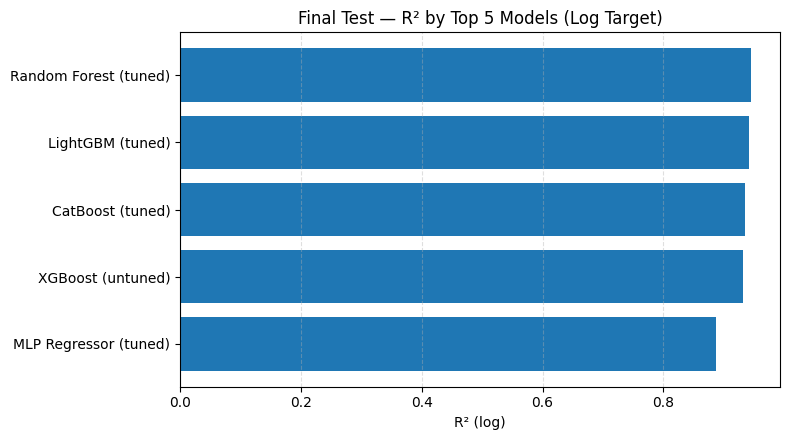

In [ ]:
import matplotlib.pyplot as plt

plot_df = final_test_df.sort_values("R²", ascending=True)

plt.figure(figsize=(8, 4.5))
plt.barh(plot_df["Model"], plot_df["R²"])
plt.xlabel("R² (log)")
plt.title("Final Test — R² by Top 5 Models (Log Target)")
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()



With the log target, the tree-based models cluster at very high R² and outperform MLP, suggesting the log transform stabilizes price variation and helps these models capture the main patterns more consistently.

 ### MAE Comparison Chart (Top 5)



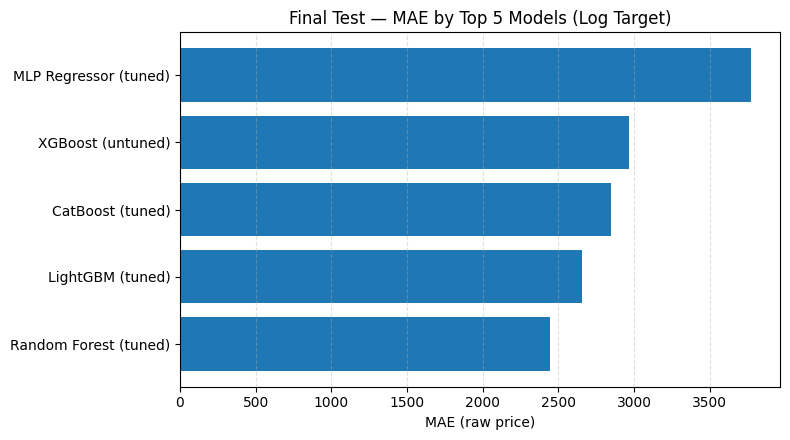

In [ ]:
plot_df = final_test_df.sort_values("MAE", ascending=True)

plt.figure(figsize=(8, 4.5))
plt.barh(plot_df["Model"], plot_df["MAE"])
plt.xlabel("MAE (raw price)")
plt.title("Final Test — MAE by Top 5 Models (Log Target)")
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()



 This likely happens because Random Forest averages many trees and handles noisy, mixed-feature used car data well, while boosting models optimize overall fit more aggressively and the MLP is limited by lighter training and struggles to match tree ensembles on this tabular price task.



 ### RMSE Comparison Chart (Top 5)



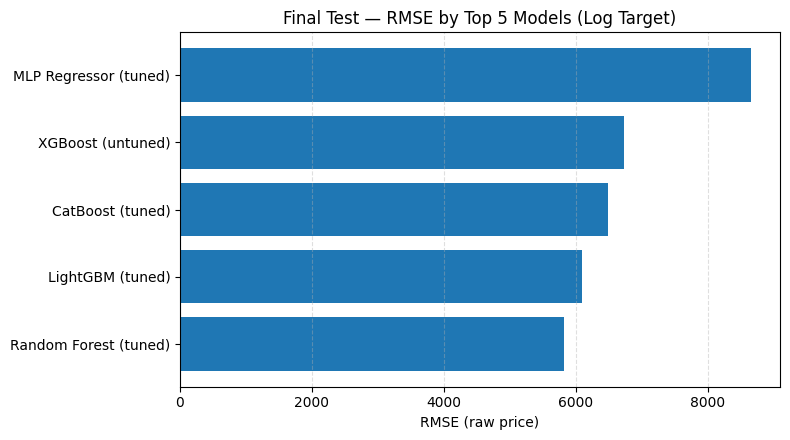

In [ ]:
plot_df = final_test_df.sort_values("RMSE", ascending=True)

plt.figure(figsize=(8, 4.5))
plt.barh(plot_df["Model"], plot_df["RMSE"])
plt.xlabel("RMSE (raw price)")
plt.title("Final Test — RMSE by Top 5 Models (Log Target)")
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()



 This likely reflects that boosted tree models handle non-linear price drivers and reduce large-error cases better in our used car data, whereas the lightly trained MLP struggles more with high-priced outliers that RMSE penalizes strongly.



 ### Trade-off Visualization - R² vs MAE



 This scatter helps summarize the performance trade-off between accuracy (R² on log scale) and error (MAE in raw units).



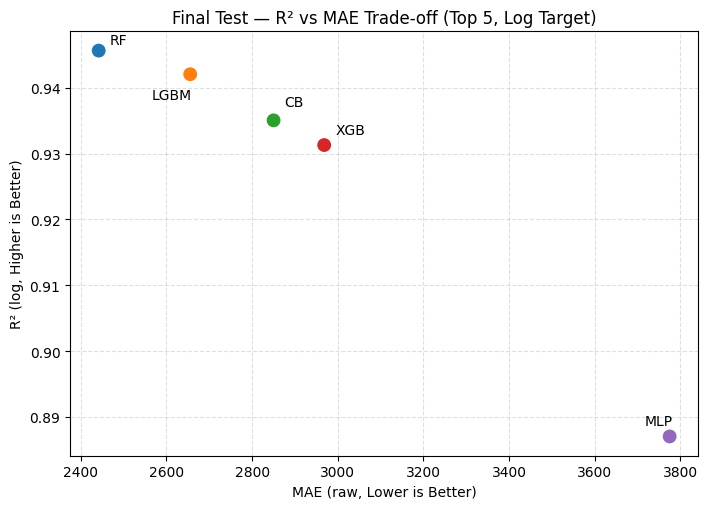

In [ ]:
label_map = {
    "Random Forest (tuned)": "RF",
    "CatBoost (tuned)": "CB",
    "LightGBM (tuned)": "LGBM",
    "XGBoost (untuned)": "XGB",
    "MLP Regressor (tuned)": "MLP"
}

plot_df = final_test_df.copy()
plot_df["Short"] = plot_df["Model"].map(label_map).fillna(plot_df["Model"])

plt.figure(figsize=(7.2, 5.2))

short_labels = plot_df["Short"].tolist()
unique_labels = list(dict.fromkeys(short_labels))
cmap = plt.cm.tab10
color_map = {lab: cmap(i) for i, lab in enumerate(unique_labels)}
colors = plot_df["Short"].map(color_map)

plt.scatter(plot_df["MAE"], plot_df["R²"], s=80, c=colors)

offsets = {
    "RF": (8, 5),
    "CB": (8, 10),
    "LGBM": (-28, -18),
    "XGB": (8, 8),
    "MLP": (-18, 8)
}

for _, row in plot_df.iterrows():
    dx, dy = offsets.get(row["Short"], (8, 8))
    plt.annotate(
        row["Short"],
        (row["MAE"], row["R²"]),
        textcoords="offset points",
        xytext=(dx, dy),
        ha="left",
        fontsize=10
    )

plt.xlabel("MAE (raw, Lower is Better)")
plt.ylabel("R² (log, Higher is Better)")
plt.title("Final Test — R² vs MAE Trade-off (Top 5, Log Target)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()



This trade-off plot shows Random Forest gives the best balance of high R² and low MAE, LightGBM is a close second, while MLP sits clearly behind the tree models with higher error despite decent R² on the log scale.

 ### Actual vs Predicted (Top 5)



 We plot a readable sample of 5,000 points per model to visualize prediction quality in original price units.



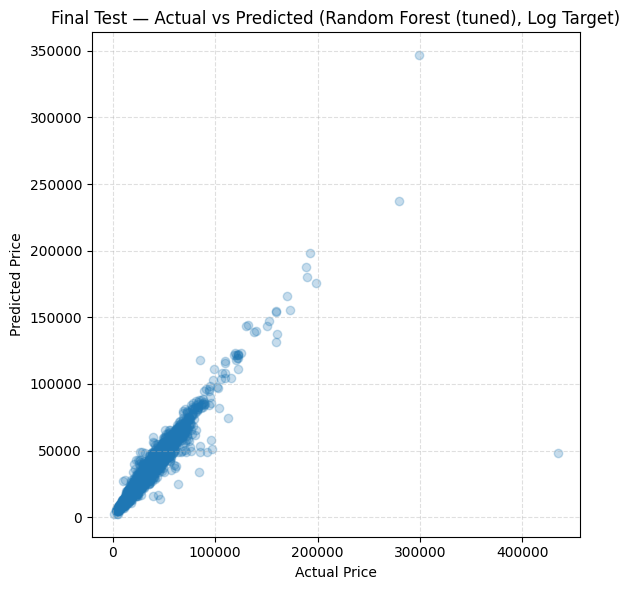

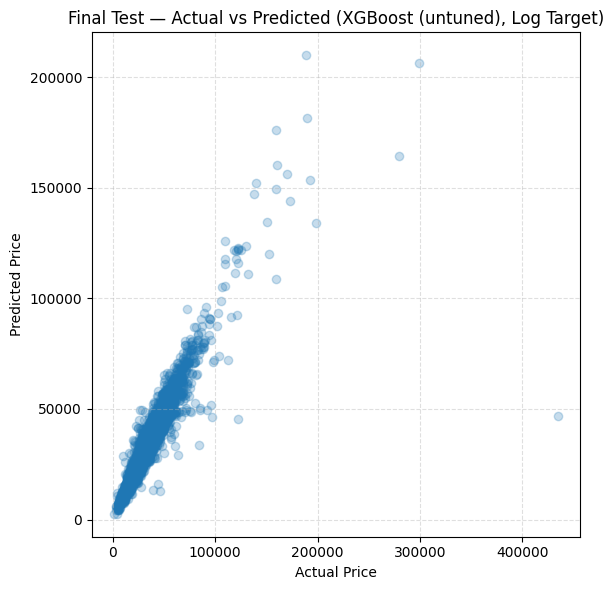

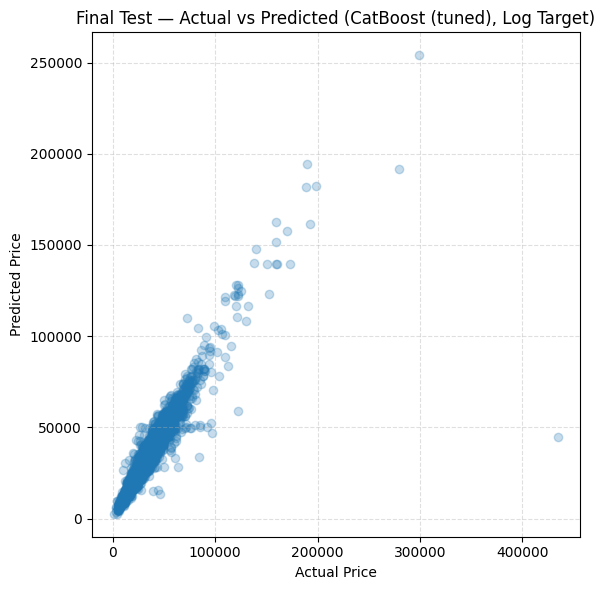

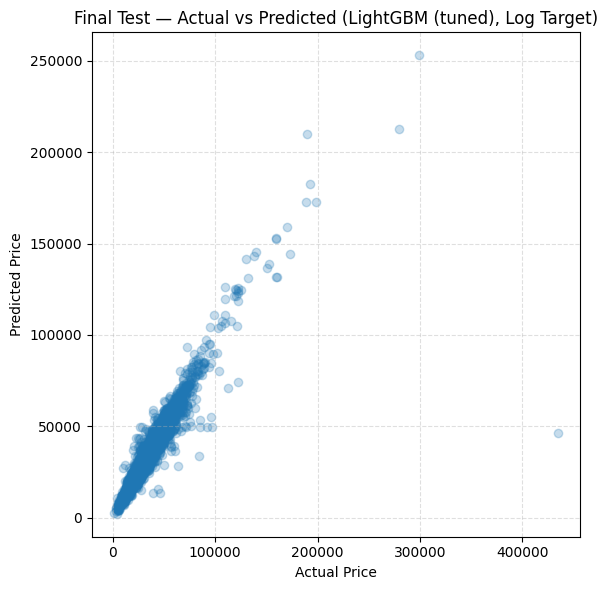

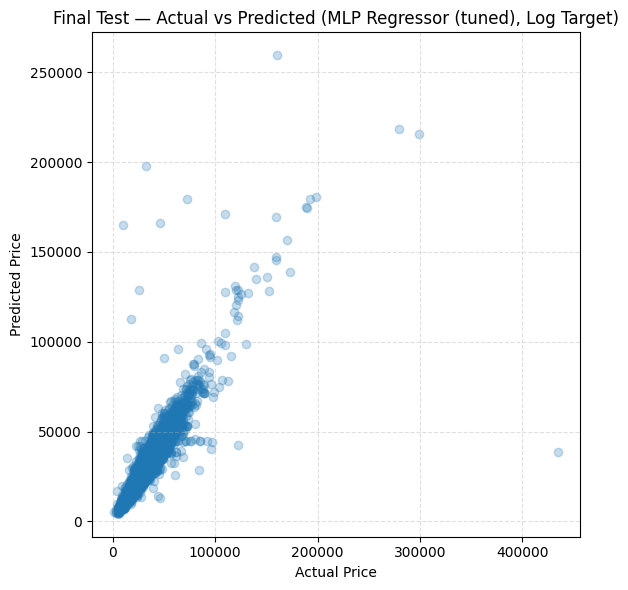

In [ ]:
sample_n = 5000

for name, preds in final_test_preds.items():
    preds_raw = np.exp(preds)

    plt.figure(figsize=(6, 6))
    plt.scatter(y_test_raw[:sample_n], preds_raw[:sample_n], alpha=0.25)
    plt.xlabel("Actual Price")
    plt.ylabel("Predicted Price")
    plt.title(f"Final Test — Actual vs Predicted ({name}, Log Target)")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()



 All five models follow the diagonal well for most cars in the common price range, but the tree-based models (Random Forest, XGBoost, CatBoost, LightGBM) show tighter clustering and fewer large deviations than MLP, while all models still struggle with rare very high-priced outliers; overall this supports the earlier metric results that tree ensembles capture the main non-linear price patterns in our used car data more reliably than the lightly trained neural network.



 ### Residual Distributions (Top 5)



 Residuals help confirm whether errors are centered and reasonably narrow, computed in original price units.



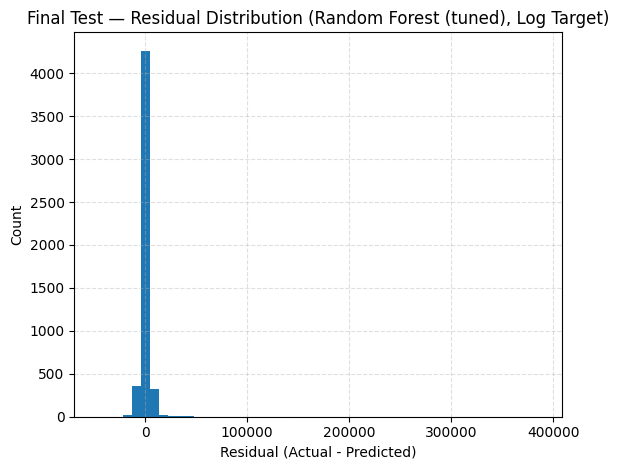

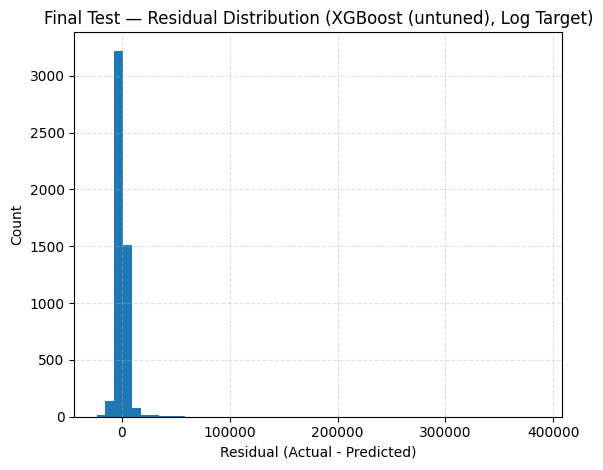

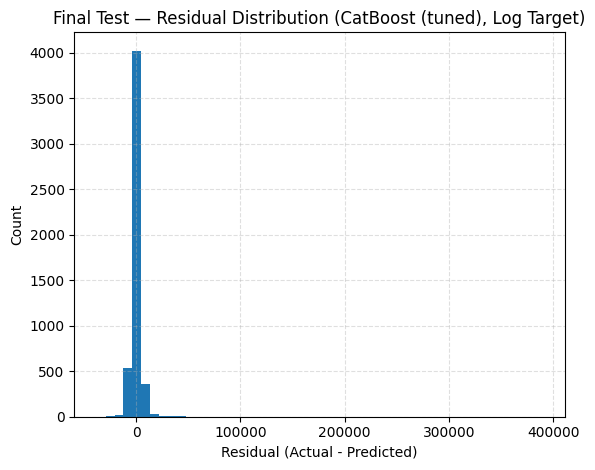

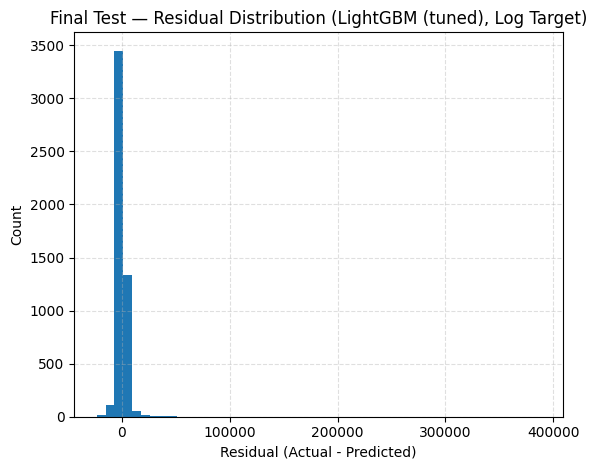

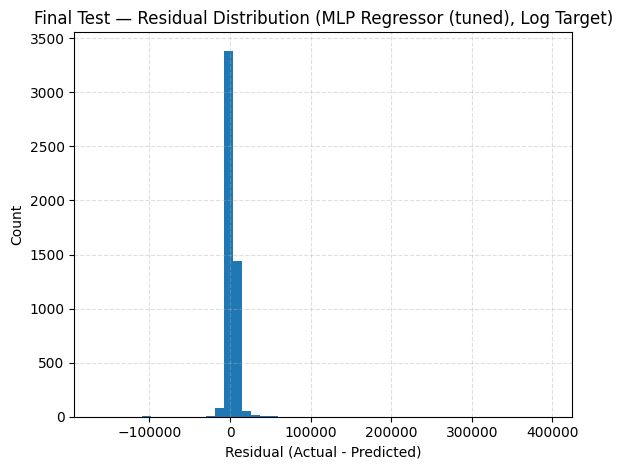

In [ ]:
sample_n = 5000

for name, preds in final_test_preds.items():
    preds_raw = np.exp(preds)
    residuals = y_test_raw[:sample_n].values - preds_raw[:sample_n]

    plt.figure(figsize=(6, 4.8))
    plt.hist(residuals, bins=50)
    plt.xlabel("Residual (Actual - Predicted)")
    plt.ylabel("Count")
    plt.title(f"Final Test — Residual Distribution ({name}, Log Target)")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()



 The residuals for the four tree-based models are tightly centered around zero with relatively narrow spread, suggesting stable and unbiased predictions for most cars, while the MLP residuals appear wider and less concentrated, aligning with its higher MAE/RMSE; across all models, a small tail of large errors remains, likely driven by rare high-priced or unusual listings that are harder to predict from the available features.



 ### Feature Importance - Tree Models (Top 5)



 We extract and visualize the top 15 features from each tuned tree model:

 - Random Forest

 - XGBoost

 - LightGBM

 - CatBoost



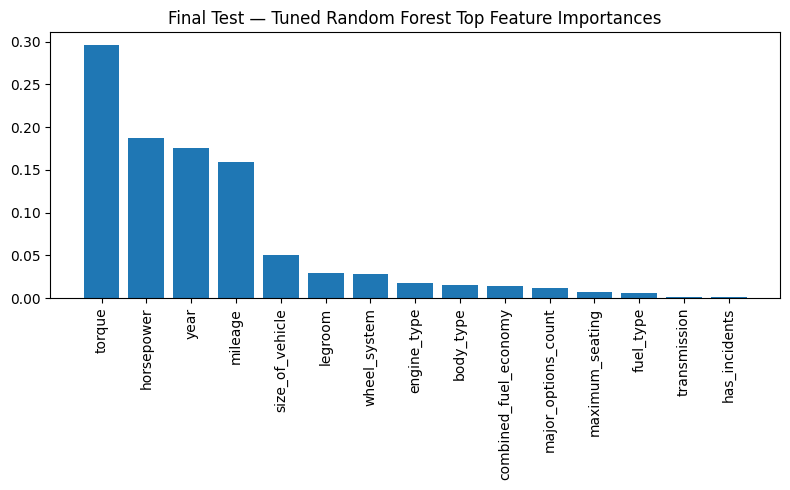

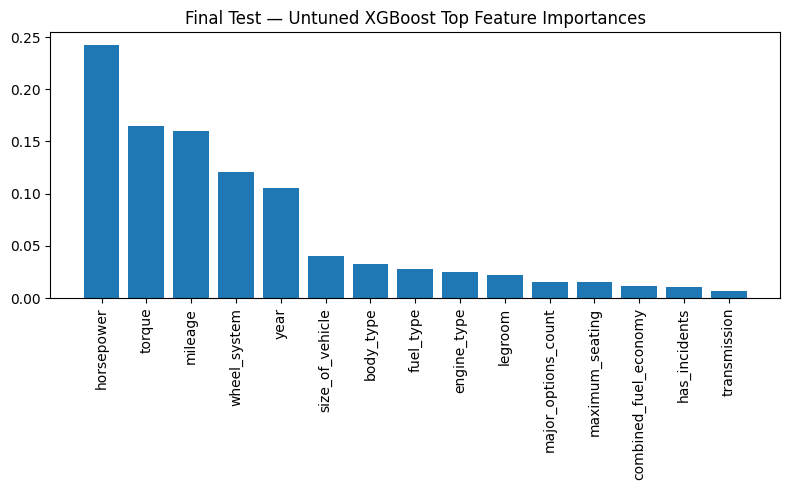

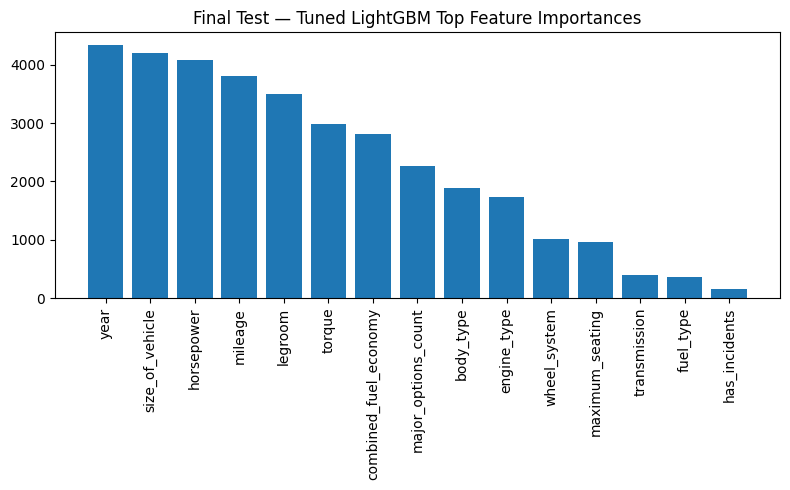

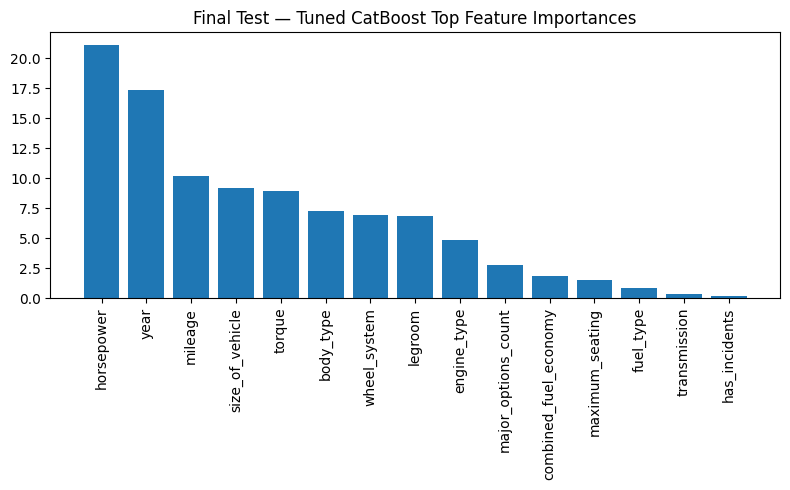

In [ ]:
top_n = 15

# Random Forest
rf_imp = (
    pd.Series(rf_tuned.feature_importances_, index=features)
    .sort_values(ascending=False)
    .head(top_n)
)
plt.figure(figsize=(8, 5))
plt.bar(rf_imp.index, rf_imp.values)
plt.xticks(rotation=90)
plt.title("Final Test — Tuned Random Forest Top Feature Importances")
plt.tight_layout()
plt.show()


# XGBoost
xgb_imp = (
    pd.Series(xgb.feature_importances_, index=features)
    .sort_values(ascending=False)
    .head(top_n)
)
plt.figure(figsize=(8, 5))
plt.bar(xgb_imp.index, xgb_imp.values)
plt.xticks(rotation=90)
plt.title("Final Test — Untuned XGBoost Top Feature Importances")
plt.tight_layout()
plt.show()


# LightGBM
lgbm_imp = (
    pd.Series(lgbm_tuned.feature_importances_, index=features)
    .sort_values(ascending=False)
    .head(top_n)
)
plt.figure(figsize=(8, 5))
plt.bar(lgbm_imp.index, lgbm_imp.values)
plt.xticks(rotation=90)
plt.title("Final Test — Tuned LightGBM Top Feature Importances")
plt.tight_layout()
plt.show()


# CatBoost
cb_imp_vals = cb_tuned.get_feature_importance()
cb_imp = (
    pd.Series(cb_imp_vals, index=features)
    .sort_values(ascending=False)
    .head(top_n)
)
plt.figure(figsize=(8, 5))
plt.bar(cb_imp.index, cb_imp.values)
plt.xticks(rotation=90)
plt.title("Final Test — Tuned CatBoost Top Feature Importances")
plt.tight_layout()
plt.show()



 Across models, the same top drivers keep showing up: horsepower, year, mileage, torque.



 - Random Forest: strongest focus on horsepower, then year and mileage.

 - XGBoost: horsepower and torque lead, with some added impact from wheel system and seating.

 - LightGBM: Year and size lead; horsepower and mileage follow.

 - CatBoost: highlights size_of_vehicle a bit more alongside horsepower and mileage.



 Overall: Across all models, engine performance (horsepower/torque), car age (year), and usage (mileage) consistently appear as the most important signals for used car price.



 ### Feature Importance - MLP (Permutation Importance)



 Neural networks do not have built-in importance like tree models,

 so we estimate importance using permutation importance on the test set.



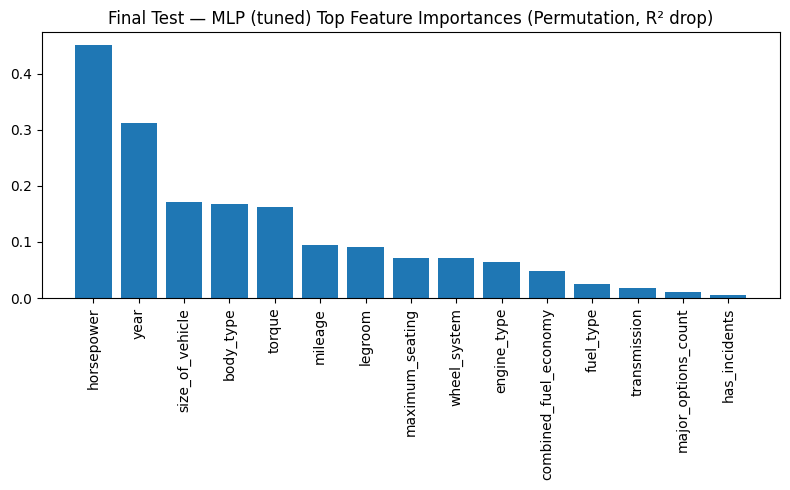

horsepower               0.451572
year                     0.312670
size_of_vehicle          0.171075
body_type                0.168513
torque                   0.162981
mileage                  0.094778
legroom                  0.091608
maximum_seating          0.071648
wheel_system             0.071234
engine_type              0.064670
combined_fuel_economy    0.048781
fuel_type                0.025581
transmission             0.018715
major_options_count      0.011551
has_incidents            0.006063
dtype: float64

In [ ]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    mlp_tuned,
    X_test_scaled,
    y_test,
    n_repeats=5,
    random_state=42,
    scoring="r2",
    n_jobs=-1
)

mlp_imp = (
    pd.Series(perm.importances_mean, index=features)
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
plt.bar(mlp_imp.head(top_n).index, mlp_imp.head(top_n).values)
plt.xticks(rotation=90)
plt.title("Final Test — MLP (tuned) Top Feature Importances (Permutation, R² drop)")
plt.tight_layout()
plt.show()

mlp_imp.head(20)



MLP vs trees: MLP aligns with trees on the same core drivers horsepower, year, mileage/size.

Difference: MLP puts a stronger emphasis on horsepower, while trees more consistently balance power + year + mileage.

Bottom line: Both tell the same story: performance and age explain most price variation.

 ## Phase 4 Conclusion

The log-target path felt like turning down the noise in a crowded market. Once we modeled price_log, the strongest models started to agree more consistently on what drives value, and the predictions looked steadier across cheap and expensive cars. 

Random Forest and LightGBM came out as the most reliable choices, giving the best mix of high R² on the log scale and low MAE/RMSE after converting back to real prices. CatBoost stayed close, while XGBoost’s default setup surprisingly held up better than our tuned version, suggesting our tuning space may have been too narrow for this dataset.

The feature story also stayed clear: power, age, and usage still shape price most (horsepower/torque, year, mileage). Overall, the log approach seems like the cleaner final route for this dataset because it handles the heavy right tail better and helps the models generalize across the full range of used car prices.